# **1. 규제 선형 회귀 모델/ 회귀 트리**
- 릿지 회귀모델 및 회귀 트리를 이용하여 전복의 나이를 예측해 보세요.

- 전복의 ‘성별’, ‘키’, ‘지름’, ‘높이’, ‘전체무게’, ‘몸통무게’, ‘내장무게’, ‘껍질무게’를 이용해 ‘껍질의 고리수’를 예측한 뒤, **예측된 ‘껍질의 고리수’에 1.5를 더하면 전복의 나이**가 됩니다.

In [1]:
# 기본 모듈 불러오기
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings(action='ignore')

### 1) 데이터 불러오기 및 데이터 선택

In [2]:
# 데이터 로드
data = pd.read_csv("abalone.csv")

# 성별 M은 Male, F는 Female, I는 Infant 이므로 따로 열 만들기
for label in "MFI":
    data[label] = data["Sex"] == label
data.drop('Sex', axis=1, inplace=True)

# X,y 데이터 선택
y = data.Rings.values
data.drop('Rings', axis=1, inplace=True)

X = data.values.astype(float)

## 2) train/test 분리
: 테스트 셋과 데이터 셋을 7:3 비율로 분리하세요.

In [3]:
# 필요한 모듈 불러오기
from sklearn.model_selection import train_test_split

In [4]:
# train과 test set 분리 (train:test = 7:3 비율로)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 제대로 분리되었는지 크기 확인
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (2923, 10), X_test shape: (1254, 10)


## 3) 릿지 모델을 이용한 모델링
: 릿지 모델을 이용하여 전복의 나이를 예측해 보고 결과를 평가해 보세요.

 3-1) 릿지모델 생성, 교차검증, 평가에 필요한 모듈을 불러오세요.

In [5]:
#필요한 모듈 불러오기
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

3-2) 릿지 모델을 생성하고 훈련하여 MSE와 RMSE를 구하세요. 릿지 모델 생성 시  alpha는 0.3으로 설정합니다. (교차 검증 하지 않습니다.)

In [8]:
#릿지모델 생성 및 훈련
ridge = Ridge(alpha=0.3)
ridge.fit(X_train, y_train)

#예측값 구하기
pred_rings = ridge.predict(X_test)

#구한 예측값을 활용해 최종적으로 전복의 나이 예측
final_pred_age = pred_rings + 1.5
actual_age = y_test + 1.5

#MSE와 RMSE구하기
mse = mean_squared_error(actual_age, final_pred_age)
rmse = np.sqrt(mse)

print(f"Ridge 모델 최종 나이 MSE: {mse:.4f}")
print(f"Ridge 모델 최종 나이 RMSE: {rmse:.4f}")

Ridge 모델 최종 나이 MSE: 4.7721
Ridge 모델 최종 나이 RMSE: 2.1845


3-3) 릿지 모델에서 회귀 계수 값을 구해 알 수 있는 점을 작성하시오. (각 컬럼의 정보는 data.colums 참고)

In [9]:
data.columns

Index(['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'M', 'F', 'I'],
      dtype='object')

플러스인 경우 값이 클수록 전복 나이가 많다는 뜻으로 껍질무게가 양수라면 나이가 많다고 해석할 수 있다. 반대로 마이너스인 경우 값이 클수록 나이가 어리다는 뜻으로 특히 성별에서 Infant 계수가 마이너스인 이유가 유아기 전복이 고리수가 적기 때문이다. 따라서 계수의 절댓값이 큰 변수들이 전복 나이를 맞추는 데 중요한 영향력을 가진다.

3-3) 교차검증을 이용하여 0, 0.1, 1, 10, 100 중  모델 성능이 가장 좋게 나오는 (rmse가 최소가 되는) alpha를 구하세요.

In [10]:
# 주어진 alpha
alphas=[0, 0.1, 1, 10, 100]

In [11]:
#alphas list 값을 반복하면서 alpha에 따른 평균 rmse를 구함
alphas = [0, 0.1, 1, 10, 100]

for alpha in alphas:
    ridge = Ridge(alpha=alpha)

    #cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산
    neg_mse_scores = cross_val_score(ridge, X_train, y_train,
                                     scoring="neg_mean_squared_error", cv=5)

    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))

    print(f'alpha {alpha}일 때 5 폴드의 평균 RMSE: {avg_rmse:.4f}')

alpha 0일 때 5 폴드의 평균 RMSE: 2.2420
alpha 0.1일 때 5 폴드의 평균 RMSE: 2.2282
alpha 1일 때 5 폴드의 평균 RMSE: 2.2152
alpha 10일 때 5 폴드의 평균 RMSE: 2.3650
alpha 100일 때 5 폴드의 평균 RMSE: 2.6364


## 4) XGBRegressor을 이용한 모델링
: XGBRegressor 모델을 이용하여 전복의 나이를 예측해 보고 결과를 평가해 보세요.

4-1) XGBRegressor 훈련, 평가에 필요한 모듈을 불러오세요.

In [12]:
# 필요한 모듈 임포트
from xgboost import XGBRegressor

4-2) XGBregressor 모델을 생성하고 훈련하여 MSE와 RMSE를 구하세요.

In [13]:
#모델 생성 및 훈련
xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_reg.fit(X_train, y_train)

#예측값 구하기
xgb_pred_rings = xgb_reg.predict(X_test)

#구한 예측값을 활용해 최종적으로 전복의 나이 예측
xgb_final_pred_age = xgb_pred_rings + 1.5
actual_age = y_test + 1.5

#MSE와 RMSE 구하기
xgb_mse = mean_squared_error(actual_age, xgb_final_pred_age)
xgb_rmse = np.sqrt(xgb_mse)

print(f"XGBoost 모델 최종 나이 MSE: {xgb_mse:.4f}")
print(f"XGBoost 모델 최종 나이 RMSE: {xgb_rmse:.4f}")

XGBoost 모델 최종 나이 MSE: 4.9244
XGBoost 모델 최종 나이 RMSE: 2.2191


4-3) 생성한 모델의 피처 중요도를 시각화해보세요.

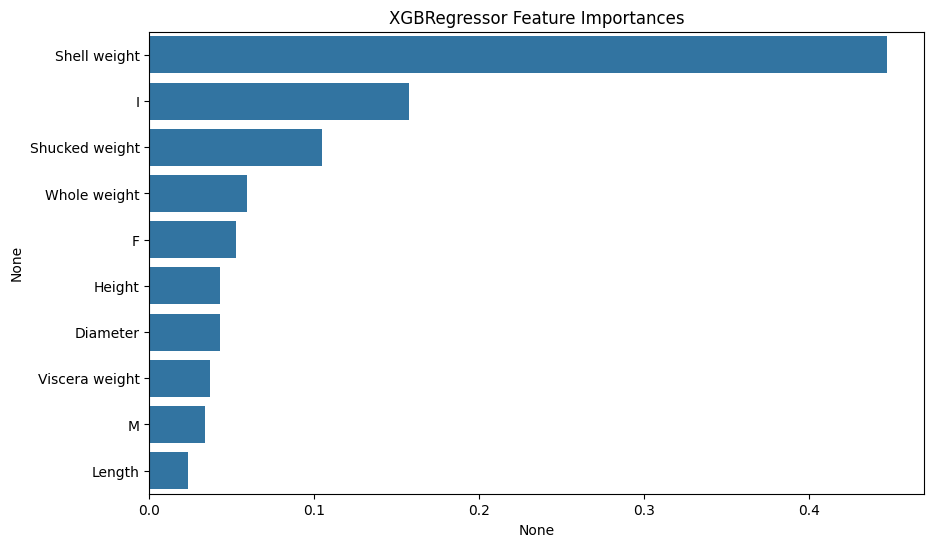

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

importances = xgb_reg.feature_importances_

# 시각화를 위해 데이터프레임으로 만들기
feat_importances = pd.Series(importances, index=data.columns)
feat_importances = feat_importances.sort_values(ascending=False)

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.title("XGBRegressor Feature Importances")
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.show()

---

# **2. 로지스틱 회귀분석**
load_wine() 함수를 이용하여 와인 데이터를 다항분류하는 로지스틱 회귀모델을 생성하세요.

In [17]:
# 필요한 모듈 불러오기
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

## 1) 데이터 불러오기 및 변수 선택

In [18]:
wine = load_wine()

wine_x = wine.data # x변수
wine_y = wine.target # y변수

## 2) train/test 셋 분리

In [21]:
x_train, x_test, y_train, y_test = train_test_split(wine_x, wine_y, test_size=0.3, random_state=123)

x_train.shape
y_train.shape

(124,)

## 3) 로지스틱 회귀모델을 이용한 모델링

3-1) 로지스틱 회귀모델을 생성하여 훈련하세요.

In [22]:
model = LogisticRegression(max_iter=3000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=3000)

3-2) 회귀 모델의 기울기와 절편을 구하세요.

In [25]:
#기울기
print(model.coef_)

[[ 0.51654501  0.555576    0.62460373 -0.25512436  0.00175921  0.25511698
   0.75996391  0.09290488  0.14917352  0.18604636 -0.00514934  0.52294
   0.00874246]
 [-0.59071789 -0.90842115 -0.6937284   0.15780781 -0.04006002  0.30082004
   0.14209725  0.04210638  0.38045684 -0.90476048  0.33211673  0.13261471
  -0.00775749]
 [ 0.07417288  0.35284515  0.06912466  0.09731655  0.03830081 -0.55593703
  -0.90206116 -0.13501126 -0.52963036  0.71871412 -0.32696739 -0.65555471
  -0.00098496]]


In [24]:
#절편
print(model.intercept_)

[-15.4802267   20.71763969  -5.237413  ]


3-3) 모델의 정확도를 구하세요.

In [27]:
#모델의 예측값 구하기
y_pred = model.predict(x_test)

#모델의 정확도 구하기
accuracy = metrics.accuracy_score(y_test, y_pred)

print(f"예측값: {y_pred}")
print(f"정확도: {accuracy:.4f}")

예측값: [2 1 2 1 1 2 0 2 2 1 2 2 2 0 0 2 1 1 0 1 2 2 2 2 1 2 2 0 0 0 0 0 1 1 2 1 2
 0 1 1 2 2 0 0 1 0 0 1 0 1 1 2 2 1]
정확도: 0.9630
